# Lab3 Model Quantization
## Setup
### Install python package

In [1]:
!pip install torch
!pip install torchinfo
!pip install torchsummary
!pip install torchvision
!pip install tqdm
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 84.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 64.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 67.2 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.

### Environment Setup

In [2]:
import os
import math
import copy
import time
import torch
import platform
import warnings
import numpy as np
import seaborn as sns
import torch.nn as nn
from torch import Tensor
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.ao.quantization as tq

from enum import Enum
from tqdm import tqdm
from typing import Tuple
from torchsummary import summary
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix

# Select device
DEFAULT_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Ignore warnings in Pytorch2.8 when using torch.ao.quantization
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Set quantization backend based on CPU architecture
machine = platform.machine().lower()
if "x86" in machine or "amd64" in machine:
    torch.backends.quantized.engine = 'fbgemm'
elif "arm" in machine or "aarch64" in machine:
    torch.backends.quantized.engine = 'qnnpack'
else:
    print("Unsupported machine:", machine)

# Check environment information
print("Pytorch version:", torch.__version__)
print(f"Using {torch.backends.quantized.engine} backend {machine}")
print("Using device:", DEFAULT_DEVICE)

Pytorch version: 2.6.0+cu124
Using fbgemm backend x86_64
Using device: cuda


### Load CIFAR-10 Dataset

In [46]:
from torchvision.transforms import RandAugment
def get_loaders(
    source, batch_size: int, transform, eval_transform=None,
    root: str = "data", split_ratio: float = 0.1
) -> Tuple[DataLoader, DataLoader, DataLoader]:
    if eval_transform is None:
        eval_transform = transform

    trainset = source(root=root, train=True, download=True, transform=transform)
    testset  = source(root=root, train=False, download=True, transform=eval_transform)

    val_len = int(split_ratio * len(trainset))
    train_len = len(trainset) - val_len
    trainset, valset = torch.utils.data.random_split(trainset, [train_len, val_len])

    loader_kwargs = dict(batch_size=batch_size, num_workers=4, pin_memory=True)
    trainloader = DataLoader(trainset, shuffle=True, **loader_kwargs)
    valloader  = DataLoader(valset, shuffle=True, **loader_kwargs)
    testloader = DataLoader(testset, shuffle=False, **loader_kwargs)

    return trainloader, valloader, testloader

def get_cifar10_loaders(batch_size: int, root="data/cifar10", split_ratio: float = 0.1):
    """
    Create CIFAR-10 training / validation / testing dataloaders.

    Args:
        batch_size (int): Number of samples per mini-batch.
        root (str): Path to download/load CIFAR-10 dataset.
        split_ratio (float): Fraction of training set to use for validation.

    Returns:
        train_loader, val_loader, test_loader (torch.utils.data.DataLoader)
    """

    train_transform = transforms.Compose([
        ##### YOUR CODE HERE #####
        # Data augmentation for training
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.RandomApply([transforms.ColorJitter(0.4,0.4,0.4,0.1)], p=0.8),
        #transforms.AutoAugment(policy=transforms.AutoAugmentPolicy.CIFAR10),
        #RandAugment(num_ops=2, magnitude=9), 
        transforms.ToTensor(),
        transforms.Normalize(
          mean=[0.4914, 0.4822, 0.4465],
          std=[0.2023, 0.1994, 0.2010]) # 此為CIFAR10的mean和std

    ])

    eval_transform = transforms.Compose([
        ##### YOUR CODE HERE #####
        # Evaluation transform

        transforms.ToTensor(),
        transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
          std=[0.2023, 0.1994, 0.2010])
    ])

    return get_loaders(
        datasets.CIFAR10, batch_size, train_transform,
        eval_transform=eval_transform, root=root, split_ratio=split_ratio
    )

if __name__ == "__main__":

    """ You can adjust the numbers below """
    BATCH_SIZE = 128
    VAL_TRAIN_SPLIT_RATIO = 0.2

    train_loader, val_loader, test_loader = get_cifar10_loaders(batch_size=BATCH_SIZE, split_ratio=VAL_TRAIN_SPLIT_RATIO)
    print(f"CIFAR-10: train={len(train_loader.dataset)}, "
            f"val={len(val_loader.dataset)}, "
            f"test={len(test_loader.dataset)}, "
            f"shape={train_loader.dataset[0][0].shape}")

CIFAR-10: train=40000, val=10000, test=10000, shape=torch.Size([3, 32, 32])


## Model Preparation
### Implement ResNet-50

In [9]:
class QuantizableBasicBlock(nn.Module):
    """
    BasicBlock for ResNet with quantization support.
    """

    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super().__init__()
        # ----- Convolution + BatchNorm + ReLU -----
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=False)

        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.downsample = downsample
        self.stride = stride

        # FloatFunctional() allows fused add+relu in quantized models
        self.add_relu = nn.quantized.FloatFunctional()

    def forward(self, x: Tensor) -> Tensor:
        identity = x

        ##### YOUR CODE HERE #####

        # Conv1 -> BN1 -> ReLU
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        # Conv2 -> BN2
        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        ##### YOUR CODE HERE #####
        # out = add + relu (skip connection)

        # 使用 add_relu 識別這邊在作融合
        out = self.add_relu.add_relu(out, identity)

        return out

    def fuse_model(self) -> None:
        """
        Fuse Conv-BN-ReLU for quantization.
        """

        ##### YOUR CODE HERE #####
        # Fuse conv+bn+relu modules

        tq.fuse_modules(self, ['conv1', 'bn1', 'relu'], inplace=True) # Corrected 'relu1' to 'relu'
        tq.fuse_modules(self, ['conv2', 'bn2'], inplace=True)

        if self.downsample:
            ##### YOUR CODE HERE #####
            # Fuse downsample conv+bn if exists
            # 如果 downsample 存在，它通常是一個 Conv + BN 的組合
            tq.fuse_modules(self.downsample, ["0", "1"], inplace=True)
            pass


class QuantizableBottleneck(nn.Module):
    """
    Bottleneck block for ResNet with quantization support.
    """

    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super().__init__()
        # 1x1 reduce
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)

        # 3x3 conv
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        # 1x1 expand
        self.conv3 = nn.Conv2d(planes, planes * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes * self.expansion)

        self.relu1 = nn.ReLU(inplace=False)
        self.relu2 = nn.ReLU(inplace=False)

        self.downsample = downsample
        self.stride = stride

        # FloatFunctional for quantized skip connection
        self.skip_add_relu = nn.quantized.FloatFunctional()

    def forward(self, x: Tensor) -> Tensor:
        identity = x

        ##### YOUR CODE HERE #####
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu2(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        ##### YOUR CODE HERE #####
        # out = add + relu (skip connection)
        out = self.skip_add_relu.add_relu(out, identity)

        return out

    def fuse_model(self) -> None:
        """
        Fuse Conv-BN-ReLU for quantization.
        """
        ##### YOUR CODE HERE #####
        # Fuse conv+bn+relu modules

        tq.fuse_modules(self, ['conv1', 'bn1', 'relu1'], inplace=True)
        tq.fuse_modules(self, ['conv2', 'bn2', 'relu2'], inplace=True)
        tq.fuse_modules(self, ['conv3', 'bn3'], inplace=True)

        if self.downsample:
            ##### YOUR CODE HERE #####
            # Fuse downsample conv+bn if exists
            tq.fuse_modules(self.downsample, ["0", "1"], inplace=True)
            pass


class QuantizableResNet(nn.Module):
    """
    ResNet model adapted for CIFAR-10 and quantization.
    """

    def __init__(self, block, layers, num_classes=10):
        super().__init__()
        self.inplanes = 64

        # CIFAR-10 uses 3x3 conv instead of 7x7
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=False)
        self.maxpool = nn.Identity() # no pooling for CIFAR-10

        # Residual layers
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        # Quantization stubs
        self.quant = tq.QuantStub()
        self.dequant = tq.DeQuantStub()

    def _make_layer(self, block, planes, blocks, stride=1):
        """
        Helper function to build ResNet layers.
        """
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))
        return nn.Sequential(*layers)

    def forward(self, x: Tensor) -> Tensor:
        ##### YOUR CODE HERE #####
        # Quantize input
        x = self.quant(x)
        # conv1 -> bn1 -> relu
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        # Pass through 4 residual layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Classification head
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        ##### YOUR CODE HERE #####
        # Dequantize output
        x = self.dequant(x)

        return x

    def fuse_model(self) -> None:
        """
        Fuse Conv-BN-ReLU layers in ResNet.
        """
        ##### YOUR CODE HERE #####
        # Fuse conv+bn+relu modules
        tq.fuse_modules(self, ['conv1', 'bn1', 'relu'], inplace=True)

        for m in self.modules():
            if type(m) is QuantizableBottleneck or type(m) is QuantizableBasicBlock:
                m.fuse_model()


def resnet50_cifar10() -> QuantizableResNet:
    """
    Construct a ResNet-50 for CIFAR-10 with quantization support.
    """
    model = QuantizableResNet(QuantizableBottleneck, [3, 4, 6, 3], num_classes=10)
    return model

### Inspect Model Architecture

In [10]:
if __name__ == "__main__":
    model = resnet50_cifar10()
    summary(model, (3, 32, 32), device= 'cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
         QuantStub-1            [-1, 3, 32, 32]               0
            Conv2d-2           [-1, 64, 32, 32]           1,728
       BatchNorm2d-3           [-1, 64, 32, 32]             128
              ReLU-4           [-1, 64, 32, 32]               0
            Conv2d-5           [-1, 64, 32, 32]           4,096
       BatchNorm2d-6           [-1, 64, 32, 32]             128
              ReLU-7           [-1, 64, 32, 32]               0
            Conv2d-8           [-1, 64, 32, 32]          36,864
       BatchNorm2d-9           [-1, 64, 32, 32]             128
             ReLU-10           [-1, 64, 32, 32]               0
           Conv2d-11          [-1, 256, 32, 32]          16,384
      BatchNorm2d-12          [-1, 256, 32, 32]             512
           Conv2d-13          [-1, 256, 32, 32]          16,384
      BatchNorm2d-14          [-1, 256,

## Utilities

In [38]:
def preprocess_filename(filename: str, existed: str = "keep_both") -> str:
    if existed == "overwrite":
        pass
    elif existed == "keep_both":
        base, ext = os.path.splitext(filename)
        cnt = 1
        while os.path.exists(filename):
            filename = f"{base}-{cnt}{ext}"
            cnt += 1
    elif existed == "raise" and os.path.exists(filename):
        raise FileExistsError(f"{filename} already exists.")
    else:
        raise ValueError(f"Unknown value for 'existed': {existed}")
    return filename

def plot_loss_accuracy(train_loss, train_acc, val_loss, val_acc, filename="loss_accuracy.png"):
    fig, (ax1, ax2) = plt.subplots(1, 2)

    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.plot(train_loss, color="tab:blue")
    ax1.plot(val_loss, color="tab:red")
    ax1.legend(["Training", "Validation"])
    ax1.set_title("Loss")

    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.plot(train_acc, color="tab:blue")
    ax2.plot(val_acc, color="tab:red")
    ax2.legend(["Training", "Validation"])
    ax2.set_title("Accuracy")

    fig.tight_layout()
    filename = preprocess_filename(filename)
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    plt.savefig(filename)
    print(f"Plot saved at {filename}")

def plot_confusion_matrix(conf_matrix, filename="conf_matrix.png"):
    classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes,
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix for CIFAR-10 Classification")
    plt.tight_layout()

    filename = preprocess_filename(filename)
    plt.savefig(filename)
    print(f"Confusion matrix saved to {filename}")

def save_model(model, filename: str, verbose: bool = True, existed: str = "keep_both") -> None:
    filename = preprocess_filename(filename, existed)

    os.makedirs(os.path.dirname(filename), exist_ok=True)
    torch.save(model.state_dict(), filename)
    if verbose:
        print(f"Model saved at {filename} ({os.path.getsize(filename) / 1e6} MB)")
    else:
        print(f"Model saved at {filename}")

def load_model(model, filename: str, qconfig=None, fuse_modules: bool = False, verbose: bool = True) -> torch.nn.Module:
    if fuse_modules and hasattr(model, "fuse_module"):
        print("Fusing modules")
        model.to('cpu').eval()
        model.fuse_model()

    if qconfig is not None:
        model.qconfig = qconfig
        qconfig_dict = {"": qconfig}
        model2 = copy.deepcopy(model)
        model_prepared = tq.prepare(model2, qconfig_dict)
        model_int8 = tq.convert(model_prepared)
        model_int8.load_state_dict(torch.load(filename, map_location='cpu', weights_only=False))
        model_int8.eval()
    else:
        device = DEFAULT_DEVICE if qconfig is None else 'cpu'
        model.load_state_dict(torch.load(filename, map_location=device, weights_only=False))

    if verbose:
        print(f"Model loaded from {filename} ({os.path.getsize(filename) / 1e6} MB)")
    return model

## Train Model
### Evaluate Function

In [12]:
def evaluate(model, dataloader, criterion, device=DEFAULT_DEVICE):
    running_loss = 0
    total, correct = 0, 0
    all_preds, all_labels = [], []

    model.eval()
    with torch.no_grad():
        loop = tqdm(dataloader, desc="Evaluating", leave=True)

        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            output = model(images)
            loss = criterion(output, labels)

            running_loss += loss.item()
            predicted = torch.argmax(output, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        loop.set_postfix(
            loss=running_loss / (total / images.shape[0]), accuracy=correct / total
        )

    avg_loss = running_loss / len(dataloader)
    accuracy = correct / total * 100
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    conf_matrix = confusion_matrix(all_labels, all_preds)
    return avg_loss, accuracy, conf_matrix

### Custom Learning Rate Scheduler

### Training Loop

In [ ]:
def train_model(model, train_loader, val_loader,
                epochs=10, lr=0.1,
                is_qat: bool = False, device=DEFAULT_DEVICE):
    """
    Train the model across multiple epochs and validate after each epoch.

    Args:
        model (nn.Module): Model to train.
        train_loader (DataLoader): Training data loader.
        val_loader (DataLoader): Validation data loader.
        epochs (int): Number of epochs to train.
        warmup_epochs (int): Warm-up epochs before cosine annealing.
        lr (float): Learning rate.
        is_qat (bool): Whether this is QAT training.
        device (str): Training device.

    Returns:
        model (nn.Module): Trained model.
    """

    ##### YOUR CODE HERE #####
    # Implement ypur criterion, optimizer, and scheduler
    criteration = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    
    best_val_acc = 0.0
    train_loss_history, train_acc_history = [], []
    val_loss_history, val_acc_history = [], []

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            # if total == 0 and epoch == 0:  # 只在第一個 epoch 的第一個 batch 印
            #   print("DEBUG: model output shape =", model(images).shape)
            #   print("DEBUG: labels sample =", labels[:32])
            #   print("DEBUG: labels dtype =", labels.dtype)
            #   print("DEBUG: first batch loss =", criteration(model(images), labels).item())
            ##### YOUR CODE HERE #####
            # 1. Zero optimizer gradients
            optimizer.zero_grad()
            # 2. Forward pass
            output = model(images)
            # 3. Compute loss
            loss = criteration(output, labels)
            # 4. Backward pass
            loss.backward()
            # 5. Optimizer step
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = output.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            pbar.set_postfix({"loss": running_loss / total})

        epoch_train_loss = running_loss / total
        epoch_train_acc = correct / total

        # ----- Validation -----
        ##### YOUR CODE HERE #####
        model.eval()
        running_loss, correct, total = 0.0, 0, 0 # Reset metrics for validation

        pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs}")
        with torch.no_grad(): # 不計算梯度以節省記憶體與運算
          for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            output = model(images)
            loss = criteration(output, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = output.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            pbar.set_postfix({"loss": running_loss / total})

        val_loss = running_loss / total
        val_acc = correct / total

        # Save history
        train_loss_history.append(epoch_train_loss)
        train_acc_history.append(epoch_train_acc)
        val_loss_history.append(val_loss)
        #val_acc_history.append(val_acc / 100.0) # 這裡好怪，為什麼要除100.0
        val_acc_history.append(val_acc)

        print(f"Epoch {epoch+1} | "
              f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc*100:.2f}% | " # Changed epoch_train_acc
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%") # 這裡也好怪，沒有*100

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            if not is_qat:
                save_model(model, "./weights/best_resnet50_cifar10.pth", existed="overwrite")
            else:
                save_model(model, "./weights/QAT_resnet50_cifar10.pth", existed="overwrite")

        if scheduler is not None:
            ##### YOUR CODE HERE #####
            scheduler.step()

    # ----- Plot loss/accuracy after training -----
    if not is_qat:
        plot_file = "./results/loss_accuracy.png"
    else:
        plot_file = "./results/QAT_loss_accuracy.png"

    plot_loss_accuracy(
        train_loss_history, train_acc_history,
        val_loss_history, val_acc_history,
        filename=plot_file
    )
    print(model(images).shape)
    return model

### Hyperparameter Configuration

In [44]:
if __name__ == "__main__":

    """ You can adjust the numbers below """
    EPOCHS = 100
    LEARNING_RATE = 0.1

    model = resnet50_cifar10().to(DEFAULT_DEVICE)
    train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE)

Epoch 1/100:   1%|          | 3/313 [00:02<03:29,  1.48it/s, loss=8.22]


KeyboardInterrupt: 

### Model Testing

Evaluating: 100%|██████████| 79/79 [00:09<00:00,  8.05it/s]


Test Accuracy: 94.16% | Loss: 0.6478
Confusion matrix saved to ./results/confusion_matrix-2.png


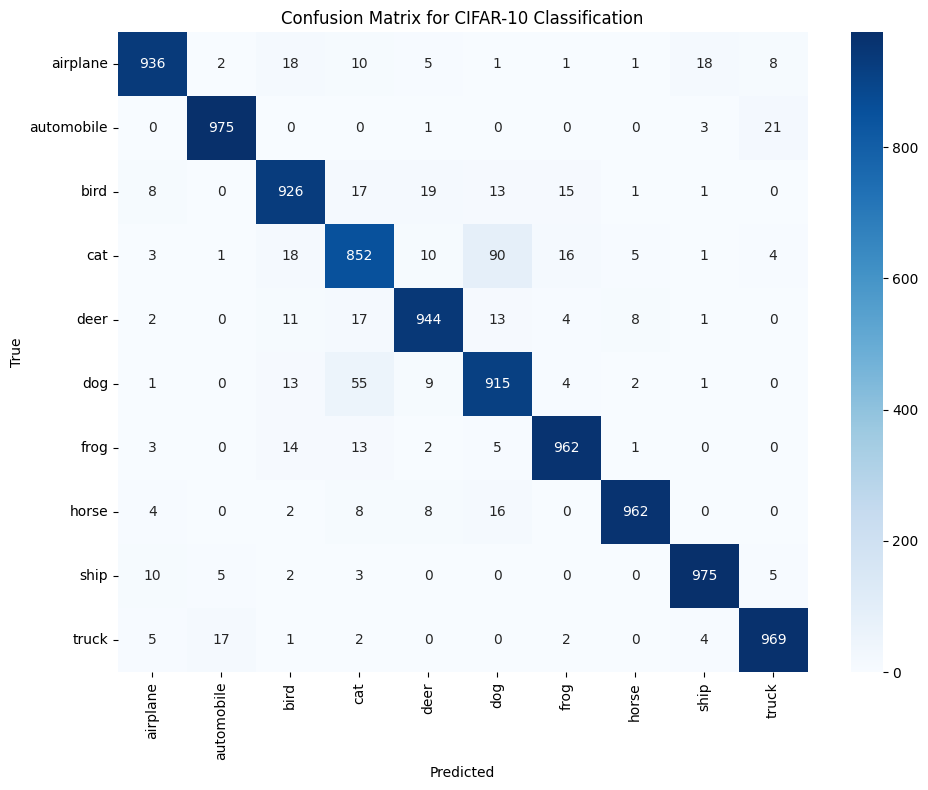

In [28]:
if __name__ == "__main__":

    ##### YOUR CODE HERE #####
    # Implement your criterion
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    model = resnet50_cifar10().to(DEFAULT_DEVICE)
    model = load_model(model, "./weights/best_resnet50_cifar10.pth", verbose=False)
    avg_loss, test_acc, conf_matrix = evaluate(model, test_loader, criterion)
    print(f"Test Accuracy: {test_acc:.2f}% | Loss: {avg_loss:.4f}")
    plot_confusion_matrix(conf_matrix, filename="./results/confusion_matrix.png")

## Post-Training Quantization (PTQ)
### Implement Quantization Function

In [18]:
class CusQuantObserver(tq.MinMaxObserver):
    """
    Observer module for your customized customize quantization scheme.
    """
    # 負責將標準的 MinMax Observer 計算出來的浮點數 scale，強制近似到最接近它的二的冪次
    def scale_approximate(self, scale: float, max_shift_amount=8) -> float:
        ##### YOUR CODE HERE #####
        # log2_scale = math.log2(scale) # 計算 log2(scale) 的值
        # shift_amount = round(log2_scale) # 將 log2_scale 四捨五入到最接近的整數 N
        # shift_amount = max(-max_shift_amount, min(shift_amount, max_shift_amount)) # 限制 shift_amount 的範圍，以避免溢出
        # approx_scale = 2.0**(shift_amount) # 計算近似後的 scale = 2^(-shift_amount)

        # 原本的 scale 有時候會變成：NaN、inf、0、負數

        if max_shift_amount is None:
            max_shift_amount = self.max_shift_amount

        # Guard for non-positive scale
        if not (scale > 0.0):
            return 1.0

        # nearest power-of-two approximation
        log2_scale = math.log2(scale)
        nearest = round(log2_scale)
        nearest = max(-max_shift_amount, min(nearest, max_shift_amount))
        approx_scale = 2.0 ** nearest
        # ensure positive non-zero
        if approx_scale <= 0.0:
            approx_scale = 1.0

        return approx_scale

    def calculate_qparams(self):
        """Calculates the quantization parameters with scale."""
        min_val, max_val = self.min_val.item(), self.max_val.item()

        """ Calculate zero_point as in the base class """
        ##### YOUR CODE HERE #####
        min_val = float(min_val)
        max_val = float(max_val)
        amax = max(abs(min_val), abs(max_val))

        # Avoid zero scale
        if amax < 1e-8:
            amax = 1e-8

        scale = amax / 127.0
        scale = self.scale_approximate(scale)
        scale = torch.tensor(scale, dtype=torch.float32)

        # Determine zero_point based on dtype
        if self.dtype == torch.qint8:
            zero_point = 0
        elif self.dtype == torch.quint8:
            zero_point = 128
        else:
            raise NotImplementedError(f"Unsupported dtype for zero_point calculation: {self.dtype}")

        zero_point = torch.tensor(zero_point, dtype=torch.int64)
        return scale, zero_point

    def extra_repr(self):
        return f"min_val={self.min_val}, max_val={self.max_val}, scale=CustomQConfig"

class CustomQConfig(Enum):
    CusQuant = tq.QConfig(
        activation=CusQuantObserver.with_args(
            dtype=torch.quint8, qscheme=torch.per_tensor_symmetric # 這邊定義了是用 Symmetric Uniform Quantization
        ),
        weight=CusQuantObserver.with_args(
            dtype=torch.qint8, qscheme=torch.per_tensor_symmetric
        ),
    )
    DEFAULT = None

### Evaluate Quantized Model

In [20]:
def test_performance(model_fp32, model_int8, dataloader, criterion,
                     is_ptq: bool = True,
                     fp32_file="./weights/best_resnet50_cifar10.pth",
                     int8_file="./weights/PTQ_resnet50_cifar10.pth"
                    ):

    device_fp32 = 'cuda' if torch.cuda.is_available() else 'cpu'
    device_int8 = 'cpu'

    model_fp32.to(device_fp32)
    model_int8.to(device_int8)


    # ----- Test accuracy & loss -----
    print("Evaluating FP32 model...")
    loss_fp32, acc_fp32, _ = evaluate(model_fp32, dataloader, criterion, device=device_fp32)
    print(f"[FP32] Loss: {loss_fp32:.4f}, Accuracy: {acc_fp32:.2f}%")

    print("Evaluating INT8 model...")
    loss_int8, acc_int8, _ = evaluate(model_int8, dataloader, criterion, device=device_int8)
    if is_ptq:
        print(f"[PTQ INT8] Loss: {loss_int8:.4f}, Accuracy: {acc_int8:.2f}%")
    else:
        print(f"[QAT INT8] Loss: {loss_int8:.4f}, Accuracy: {acc_int8:.2f}%")


    # ----- Test latency -----
    model_fp32.to('cpu')
    dummy_input = torch.randn(1, 3, 32, 32).to('cpu')

    # FP32
    t0 = time.time()
    with torch.no_grad():
        for _ in range(1000):
            _ = model_fp32(dummy_input)
    t1 = time.time()
    fp32_time = (t1 - t0) / 1000

    # INT8
    t0 = time.time()
    with torch.no_grad():
        for _ in range(1000):
            _ = model_int8(dummy_input)
    t1 = time.time()
    int8_time = (t1 - t0) / 1000

    if is_ptq:
        print(f"[Latency] FP32: {fp32_time*1000:.3f} ms | PTQ INT8: {int8_time*1000:.3f} ms")
    else:
        print(f"[Latency] FP32: {fp32_time*1000:.3f} ms | QAT INT8: {int8_time*1000:.3f} ms")
    print(f"[Speedup] ~{fp32_time/int8_time:.2f}x faster")


    # ----- Compare file size -----
    if os.path.exists(fp32_file) and os.path.exists(int8_file):
        size_fp32 = os.path.getsize(fp32_file) / 1e6
        size_int8 = os.path.getsize(int8_file) / 1e6
        if is_ptq:
            print(f"[File size] FP32: {size_fp32:.2f} MB | PTQ INT8: {size_int8:.2f} MB")
        else:
            print(f"[File size] FP32: {size_fp32:.2f} MB | QAT INT8: {size_int8:.2f} MB")
        print(f"[Compression] ~{size_fp32/size_int8:.2f}x smaller")
    else:
        print("Warning: model files not found. Skipping file size comparison.")

### Run PTQ Workflow

In [22]:
def calibrate(model, loader, device= 'cpu'):
    """
    Run one pass of calibration on the dataset to collect statistics
    for quantization (e.g., min/max values of activations).

    Args:
        model (nn.Module): The model prepared for quantization.
        loader (DataLoader): Data loader for calibration dataset.
        device (str): Device to run calibration on.
    """
    ##### YOUR CODE HERE #####
    model.eval().to(device)
    count = 0
    with torch.no_grad():
      for x, _ in loader:
          model(x.to(device))
          count += 1
          if count >= 200: # 至少跑 10–20 個 batch
            break

def ptq_quantization():
    """
    Perform Post-Training Quantization (PTQ) on the trained ResNet-50 model.

    Steps:
        1. Load CIFAR-10 validation set
        2. Load trained FP32 model
        3. Fuse model layers
        4. Prepare model for PTQ
        5. Calibrate using validation data
        6. Convert model to INT8
        7. Save quantized model
    Returns:
        model_int8 (nn.Module): The INT8 quantized model after PTQ
    """
    # 1. Data
    _, val_loader, _ = get_cifar10_loaders(batch_size=64)

    # 2. Load model (FP32 baseline)
    fp32_checkpoint = "./weights/best_resnet50_cifar10.pth"
    model_fp32 = load_model(resnet50_cifar10(), fp32_checkpoint)

    ##### YOUR CODE HERE #####
    # Set model to evaluation mode before fusing
    model_fp32.eval()
    # 3. Fuse layers
    model_fp32.fuse_model()

    # 4. Prepare PTQ
    model_fp32.qconfig = CustomQConfig.CusQuant.value # Access the QConfig object # 加 .value
    model_prepared = tq.prepare(model_fp32)

    # 5. Calibrate
    calibrate(model_prepared, val_loader, device='cpu')

    # 6. Convert to INT8
    model_int8 = tq.convert(model_prepared)

    # 7. Save INT8 model
    save_model(model_int8, "./weights/PTQ_resnet50_cifar10.pth", existed="overwrite")

    return model_int8

### Compare FP32 vs Quantized Results

In [23]:
if __name__ == "__main__":
    model_int8 = ptq_quantization()

    ##### YOUR CODE HERE #####
    # Implement your criterion
    criterion = nn.CrossEntropyLoss()
    fp32_checkpoint = "./weights/best_resnet50_cifar10.pth"
    model_baseline = load_model(resnet50_cifar10(), fp32_checkpoint, verbose=True)
    test_performance(model_baseline, model_int8, test_loader, criterion, is_ptq=True)

Model loaded from ./weights/best_resnet50_cifar10.pth (94.407978 MB)
Model saved at ./weights/PTQ_resnet50_cifar10.pth (23.660708 MB)
Model loaded from ./weights/best_resnet50_cifar10.pth (94.407978 MB)
Evaluating FP32 model...


Evaluating: 100%|██████████| 79/79 [00:10<00:00,  7.76it/s]


[FP32] Loss: 0.2687, Accuracy: 93.58%
Evaluating INT8 model...


Evaluating: 100%|██████████| 79/79 [01:42<00:00,  1.30s/it]


[PTQ INT8] Loss: 0.2897, Accuracy: 93.02%
[Latency] FP32: 36.151 ms | PTQ INT8: 15.962 ms
[Speedup] ~2.26x faster
[File size] FP32: 94.41 MB | PTQ INT8: 23.66 MB
[Compression] ~3.99x smaller


## Quantization-Aware Training (QAT)
### Run QAT Workflow

Model loaded from ./weights/best_resnet50_cifar10.pth (94.407978 MB)


Epoch 1/2: 100%|██████████| 79/79 [00:05<00:00, 14.40it/s, loss=0.652]


Epoch 1 | Train Loss: 0.6569 | Train Acc: 93.24% | Val Loss: 0.6516 | Val Acc: 93.52%
Model saved at ./weights/QAT_resnet50_cifar10.pth (94.151975 MB)


Epoch 2/2: 100%|██████████| 79/79 [00:05<00:00, 14.49it/s, loss=0.639]


Epoch 2 | Train Loss: 0.6325 | Train Acc: 94.36% | Val Loss: 0.6388 | Val Acc: 94.02%
Model saved at ./weights/QAT_resnet50_cifar10.pth (94.151975 MB)
Plot saved at ./results/QAT_loss_accuracy.png
torch.Size([8, 10])


...

Epoch 8 | Train Loss: 0.6196 | Train Acc: 94.89% | Val Loss: 0.6241 | Val Acc: 94.58%
Plot saved at ./results/QAT_loss_accuracy-1.png
torch.Size([8, 10])
Model saved at ./weights/QAT_resnet50_cifar10.pth (23.660708 MB)
Evaluating FP32 model...


Evaluating: 100%|██████████| 79/79 [00:09<00:00,  8.41it/s]


[FP32] Loss: 0.2687, Accuracy: 93.58%
Evaluating INT8 model...


Evaluating: 100%|██████████| 79/79 [01:44<00:00,  1.32s/it]


[QAT INT8] Loss: 0.2798, Accuracy: 93.36%
[Latency] FP32: 36.293 ms | QAT INT8: 16.416 ms
[Speedup] ~2.21x faster
[File size] FP32: 94.41 MB | QAT INT8: 23.66 MB
[Compression] ~3.99x smaller


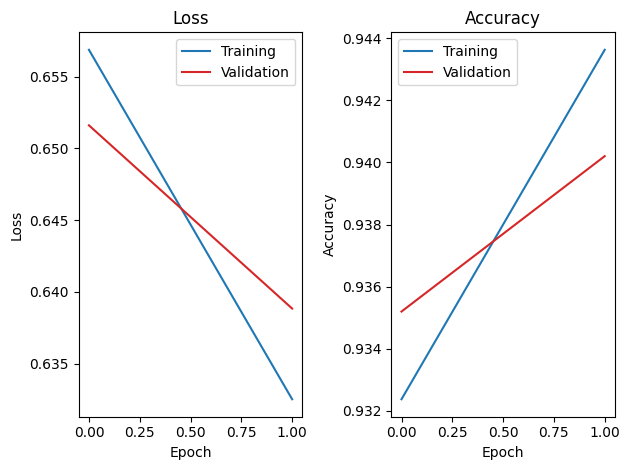

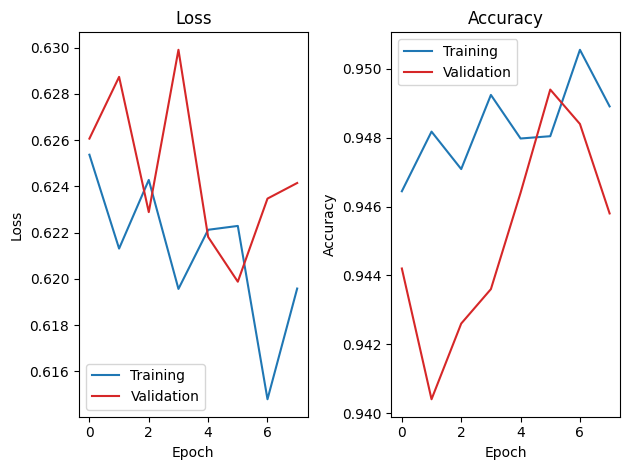

In [25]:
def qat_quantization():
    """
    Run Quantization-Aware Training (QAT) workflow on ResNet-50 for CIFAR-10.

    Steps:
        0. Prepare CIFAR-10 dataloaders
        1. Load pretrained FP32 model
        2. Fuse model layers
        3. Assign QAT qconfig
        4. Prepare model for QAT
        5. Train with QAT
        6. Convert to INT8 model
        7. Save quantized model
    Returns:
        model_int8 (nn.Module): The INT8 quantized model after QAT
    """
    # 1. Data
    train_loader, val_loader, test_loader = get_cifar10_loaders(batch_size=64)

    # 2. Load model (FP32 baseline)
    fp32_checkpoint = "./weights/best_resnet50_cifar10.pth"
    model_fp32 = load_model(resnet50_cifar10(), fp32_checkpoint)

    ##### YOUR CODE HERE #####
    # Set model to evaluation mode before fusing
    model_fp32.eval()
    # 3. Fuse layers before QAT
    model_fp32.fuse_model()

    # Set model to training mode before prepare_qat
    model_fp32.train()

    # 4. Set qconfig to enable QAT
    model_fp32.qconfig = CustomQConfig.CusQuant.value # Access the QConfig object

    # 5. Prepare model
    model_fp32 = tq.prepare_qat(model_fp32)
    model_fp32.to(DEFAULT_DEVICE) # Move the prepared model to the default device (GPU if available)
    model_fp32.train()

    # 6. Run QAT training
    # Use train_model(is_qat=True, ...)
    warmup_epochs = 2
    warmup_lr = 1e-3   # modest LR for warmup (not 0.1)
    train_model(model_fp32, train_loader, val_loader, epochs=warmup_epochs, lr=warmup_lr, is_qat=True)

    tq.disable_observer(model_fp32)
    for m in model_fp32.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.eval()

    finetune_epochs = 8
    finetune_lr = 1e-4
    train_model(model_fp32, train_loader, val_loader, epochs=finetune_epochs, lr=finetune_lr, is_qat=True)

    model_fp32.to('cpu')
    model_fp32.eval()

    # 7. Convert to INT8
    model_int8 = tq.convert(model_fp32)

    # 8. Save INT8 model
    save_model(model_int8, "./weights/QAT_resnet50_cifar10.pth", existed="overwrite")

    return model_int8

if __name__ == "__main__":
    model_int8 = qat_quantization()

    ##### YOUR CODE HERE #####
    # Implement your criterion
    criterion = nn.CrossEntropyLoss()

    fp32_checkpoint = "./weights/best_resnet50_cifar10.pth"
    model_baseline = load_model(resnet50_cifar10(), fp32_checkpoint, verbose=False)
    test_performance(model_baseline, model_int8, test_loader, criterion, is_ptq=False,
                    fp32_file=fp32_checkpoint, int8_file="./weights/QAT_resnet50_cifar10.pth")